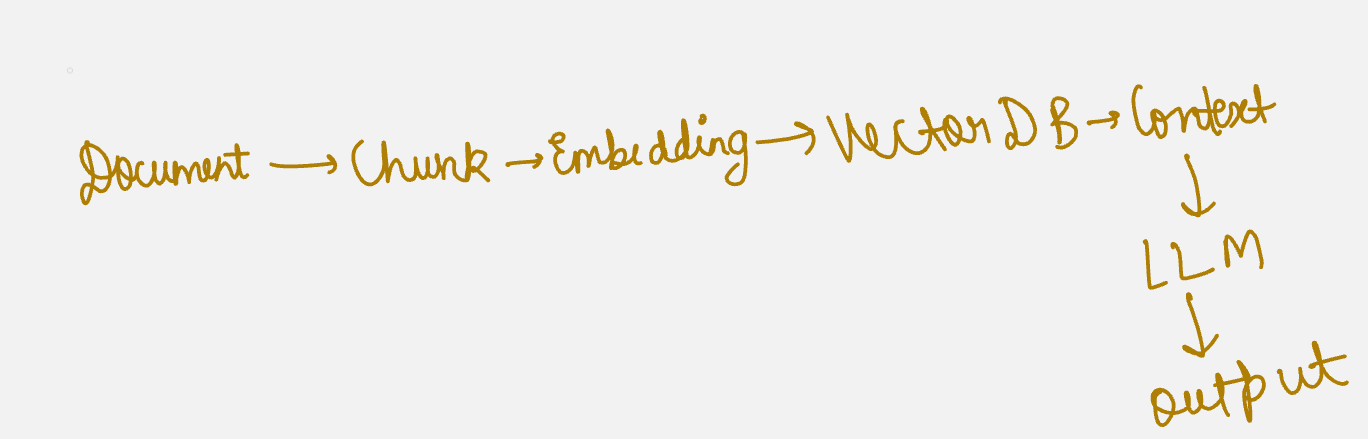

### Install Libraries

In [1]:
!pip install -qU langchain-google-genai langchain-community langchain chromadb

**langchain -> helps connect everything**

-> **langchain-google-genai-** to use google gemini

-> **langchain-community-** extra tools

-> **chromadb-** stores data as vectors

In [2]:
from langchain_community.document_loaders import TextLoader # load text file
from langchain_text_splitters import RecursiveCharacterTextSplitter # split big text into smaller chunks
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI # embedding(convert text to vectors)
from langchain_community.vectorstores import Chroma # store data in vector database
from langchain_core.prompts import ChatPromptTemplate # helps create structured context
from langchain_core.output_parsers import StrOutputParser # convert output into normal text
from langchain_core.runnables import RunnablePassthrough # passes user query directly to chain 

C:\Users\karan\AppData\Local\Temp\ipykernel_22652\3209475959.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader # load text file


**import basic python tools**

In [3]:
import os # operating system module
import getpass # secret input tool ->  hide input (like password)
import sys # system

In [4]:
GOOGLE_API_KEY = ""
os.environ['GOOGLE_API_KEY'] = GOOGLE_API_KEY
# environ -> special storage place
# So overall it means a locker where import values are kept

In [5]:
# check whether key exists or not
def setup_env():
  if os.getenv('GOOGLE_API_KEY'):
    os.environ['GOOGLE_API_KEY']= getpass.getpass("Enter your google API key")

### Loader and Splitter

In [6]:
def load_and_split(filepath):
    if not os.path.exists(filepath):
        print(f'Error: File not Found at {filepath}')
        sys.exit(1)

    print(f'Loading Data')
    loader = TextLoader(filepath, encoding = 'utf-8', autodetect_encoding=True)
    # For pdf -> loader = PyPDFLoader(filepath)
    docs = loader.load()
    # read file -> converts into documents

    print(f'Splitting Data')
    splitter = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 200)
    # max character = 500 -> chunk_size
    # overlap = 200 -> chunk_overlap
    splits = splitter.split_documents(docs) # Final Chunks ready
    print(f'Split {len(splits)} chunks')
    return splits

**CREATING A RAG CHAIN -> embedding , vector database**

In [7]:
def create_rag_chain(splits):
    embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001", task_type="retrieval_document")

    # Store in Vector DB
    vectorstore = Chroma.from_documents(documents = splits, embedding = embeddings)
    # Retriever -> Vector Search (Search Engine)
    retriever = vectorstore.as_retriever()

    llm = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash', temperature = 0)
    # temperature = 0 -> fixed /determinstic answer -> no randomess
    # Create a context/prompt Template

    template = """Answer the question based only on the following context: {context}
    Question: {question}"""

    prompt = ChatPromptTemplate.from_template(template) # converting string -> usable prompt
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    chain = (
        {"context": retriever | format_docs, 'question': RunnablePassthrough()}
            | prompt
            | llm
            | StrOutputParser())
    return chain

In [8]:
filepath = "harrypotter.txt"
splits = load_and_split(filepath)
rag_chain = create_rag_chain(splits)

Loading Data
Splitting Data
Split 15 chunks


ValidationError: 1 validation error for GoogleGenerativeAIEmbeddings
  Value error, API key required for Gemini Developer API. Provide api_key parameter or set GOOGLE_API_KEY/GEMINI_API_KEY environment variable. [type=value_error, input_value={'model': 'gemini-embeddi...': 'retrieval_document'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.10/v/value_error

In [ ]:
message = input('Ask Question: ')
output = rag_chain.invoke(message)
print(output)